In [80]:
import torch
import torch.nn.functional as F
import numpy as np
import os

from models.mini_raft_stereo import MiniRAFTStereo
from data.sceneflow_test_dataset import SceneFlowStereoTest
from transforms.stereo_compose import StereoCompose
import torchvision.transforms as T


In [81]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [82]:
ckpt_path = "mini_raft_kitti.pth"

model = MiniRAFTStereo().to(device)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

print("Loaded checkpoint:", ckpt_path)


Loaded checkpoint: mini_raft_kitti.pth


In [83]:
sceneflow_root = "/home/rahul/AiStätt/RAFT/data/data_scene_flow/testing"   # KIITTI path local.
compose = StereoCompose(
    T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
)

def transform(sample):
    return compose(sample)




In [84]:
test_dataset = SceneFlowStereoTest(sceneflow_root, transform=transform)
print("Number of test samples:", len(test_dataset))

Loading SceneFlow test dataset...
Loading SceneFlow test dataset...
Number of test samples: 1


In [85]:
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import os
import torchvision.transforms as T
from models.mini_raft_stereo import MiniRAFTStereo

def load_and_predict_first(test_root, model_path):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # -----------------------------
    # 1. Load model
    # -----------------------------
    model = MiniRAFTStereo().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # -----------------------------
    # 2. Get first left/right image paths
    # -----------------------------
    left_dir = os.path.join(test_root, "image_2")
    right_dir = os.path.join(test_root, "image_3")

    left_path = sorted(os.listdir(left_dir))[0]
    right_path = sorted(os.listdir(right_dir))[0]

    left_img = Image.open(os.path.join(left_dir, left_path)).convert("RGB")
    right_img = Image.open(os.path.join(right_dir, right_path)).convert("RGB")

    # -----------------------------
    # 3. Transform images
    # -----------------------------
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    left = transform(left_img).unsqueeze(0).to(device)
    right = transform(right_img).unsqueeze(0).to(device)

    # -----------------------------
    # 4. Run inference
    # -----------------------------
    with torch.no_grad():
        preds = model(left, right)
        disp_pred = preds[-1]  # final output

    # Upsample to full resolution
    disp_full = F.interpolate(
        disp_pred, scale_factor=4, mode="bilinear", align_corners=False
    ).cpu().numpy()[0, 0]

    return disp_full, left_img, right_img


In [86]:

test_root = "/home/rahul/AiStätt/RAFT/data/data_scene_flow/testing"   # KIITTI path local.
model_path = "mini_raft_kitti.pth"

disp, left_img, right_img = load_and_predict_first(test_root, model_path)

print("Disparity shape:", disp.shape)
print("Mean disparity:", disp.mean())


Disparity shape: (1024, 1536)
Mean disparity: 18.952873


In [87]:
def depth_from_disparity(disp, f=700, baseline=0.54):
    disp_safe = np.where(disp > 0, disp, 0.1)
    depth = (f * baseline) / disp_safe
    return depth


In [88]:
depth = depth_from_disparity(disp)

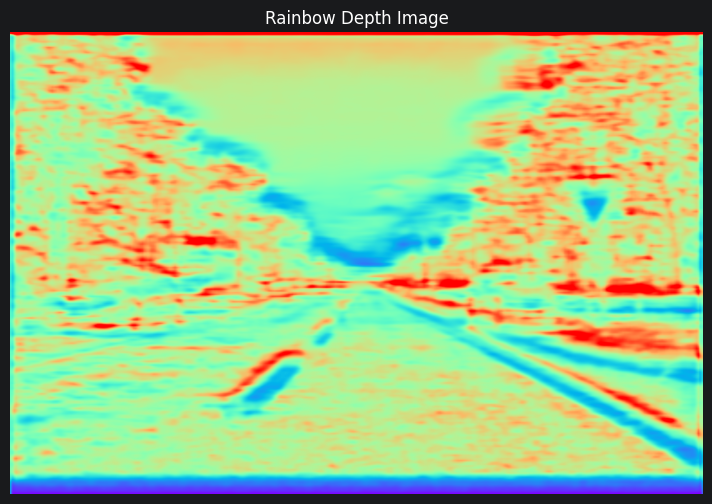

In [89]:
# 1. Convert disparity → depth
depth = depth_from_disparity(disp)

# 2. Normalize depth to 0–1
d = depth.copy()
d = np.clip(d, 0, np.percentile(d, 99))
d = d - d.min()
d = d / d.max()

# 3. Apply rainbow colormap (JET)
colored = plt.get_cmap("rainbow")(d)[:, :, :3]

# 4. Show the image
plt.figure(figsize=(10,6))
plt.imshow(colored)
plt.title("Rainbow Depth Image")
plt.axis('off')
plt.show()


In [90]:
def depth_from_disparity(disp, f=700, baseline=0.54):
    disp_safe = np.where(disp > 0, disp, 0.1)
    depth = (f * baseline) / disp_safe
    return depth


In [91]:
d = depth.copy()
d = np.clip(d, 0, np.percentile(d, 99))
d = d - d.min()
d = d / d.max()


In [92]:
import matplotlib.pyplot as plt

colored = plt.get_cmap("rainbow")(d)[:, :, :3]


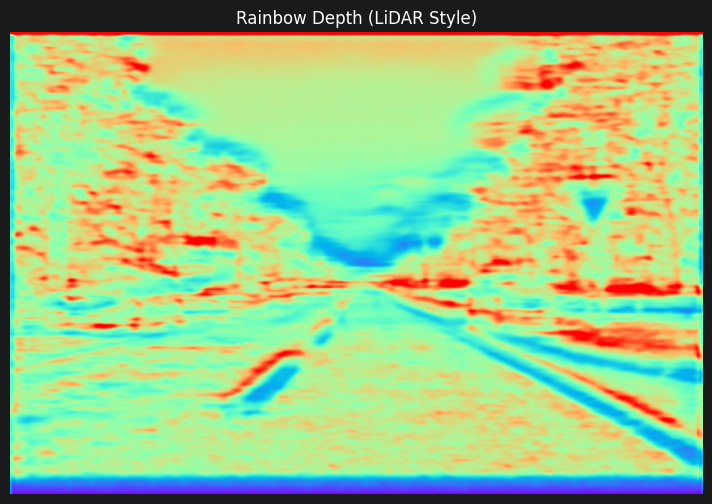

In [93]:
plt.figure(figsize=(10,6))
plt.imshow(colored)
plt.title("Rainbow Depth (LiDAR Style)")
plt.axis('off')
plt.show()


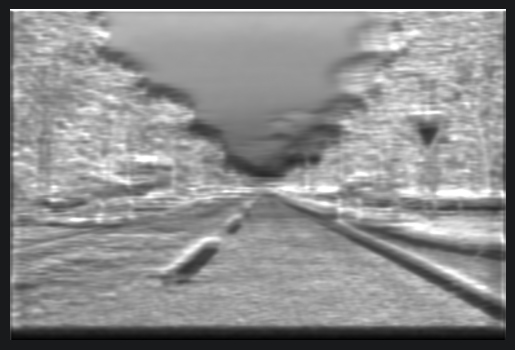

In [94]:
depth = depth_from_disparity(disp)

d = depth.copy()
d = np.clip(d, 0, np.percentile(d, 99))
d = d - d.min()
d = d / d.max()

plt.imshow(d, cmap='gray')
plt.axis('off')
plt.show()


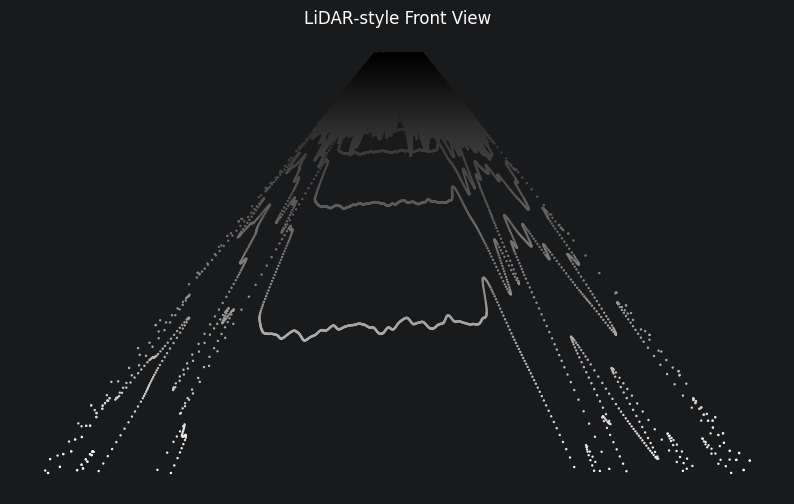

In [95]:
# 1. You already computed depth and d (grayscale depth)

# 2. Intrinsics
h, w = depth.shape
fx = 0.9 * w
fy = fx
cx = w / 2
cy = h / 2

# 3. Depth → point cloud
u, v = np.meshgrid(np.arange(w), np.arange(h))

Z = depth
X = (u - cx) * Z / fx
Y = (v - cy) * Z / fy

pc = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)

# 4. Filter valid LiDAR range
valid = pc[(pc[:,2] > 0.5) & (pc[:,2] < 120)]

# 5. LiDAR‑style front view
plt.figure(figsize=(10,6))
plt.scatter(valid[:,0], valid[:,2], s=0.5, c=valid[:,2], cmap='gray')
plt.gca().invert_yaxis()
plt.axis('off')
plt.title("LiDAR‑style Front View")
plt.show()
